In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

In [3]:
path = '/n/holystore01/LABS/iaifi_lab/Lab/nswood/training/JetClass/Pythia/kinpid/PMTrans/'



all_output_folders = glob.glob(path + "*/*gromov_analysis.csv")


In [4]:
def calculate_accuracies(csv_file):
    test_csv = pd.read_csv(csv_file)
    
    num_splits = test_csv['Decile_idx'].max()
    full_acc = test_csv['Correct'].sum() / (test_csv['Correct'].sum() + test_csv['Incorrect'].sum())
    
    results = []
    
    classes = test_csv['Class'].unique()
    
    # Full accuracy
    results.append({'Level': 'Full', 'Class': 'Overall', 'Accuracy': full_acc})
    
    for c in classes:
        class_mask = test_csv['Class'] == c
        class_acc = test_csv[class_mask]['Correct'].sum() / (test_csv[class_mask]['Correct'].sum() + test_csv[class_mask]['Incorrect'].sum())
        results.append({'Level': 'Full', 'Class': c, 'Accuracy': class_acc})
    
    # Gromov filterings
    for i in range(num_splits, 0, -1):
        decile_mask = test_csv['Decile_idx'] < i
        gromov_max = test_csv[decile_mask]['Decile'].str.split('-').str[1].astype(float).max()
        
        decile_accuracy = test_csv[decile_mask]['Correct'].sum() / (test_csv[decile_mask]['Correct'].sum() + test_csv[decile_mask]['Incorrect'].sum())
        results.append({'Level': f'Decile {i-1}', 'Class': 'Overall', 'Accuracy': decile_accuracy, 'Gromov Max': np.round(gromov_max, 4)})
        
        for c in classes:
            class_mask = test_csv['Class'] == c
            class_acc = test_csv[class_mask & decile_mask]['Correct'].sum() / (test_csv[class_mask & decile_mask]['Correct'].sum() + test_csv[class_mask & decile_mask]['Incorrect'].sum())
            results.append({'Level': f'Decile {i-1}', 'Class': c, 'Accuracy': class_acc, 'Gromov Max': np.round(gromov_max, 4)})
    
    results_df = pd.DataFrame(results)
    return results_df

# Example usage
csv_file = all_output_folders[0]
accuracies_df = calculate_accuracies(csv_file)
display(accuracies_df)

,Level,Class,Accuracy,Gromov Max
0,Full,Overall,0.633634,NaN
1,Full,HToWW2Q1L,0.818440,NaN
2,Full,HToBB,0.446740,NaN
3,Full,HToWW4Q,0.688950,NaN
4,Full,TTBar,0.845328,NaN
5,Full,ZJetsToNuNu,0.680835,NaN
6,Full,HToGG,0.615360,NaN
7,Full,WToQQ,0.667880,NaN
8,Full,ZToQQ,0.342690,NaN
9,Full,TTBarLep,0.883940,NaN


In [54]:
def process_csv_files(csv_paths):
    combined_results = []

    for csv_file in csv_paths:
        model_name = csv_file.split('/')[-1].split('_results')[0]
        geom_name = model_name.split('_')[0]
        geom_dims = model_name.split('_')[1]
        split_geom_dims = geom_dims.split(',')
        if len(split_geom_dims) == 1:
            geom_ratio = 1
        else:
            geom_ratio = float(split_geom_dims[0]) / float(split_geom_dims[1])

        geom_curv = model_name.split('_')[2]

        accuracies_df = calculate_accuracies(csv_file)
        accuracies_df['geom'] = geom_name
        accuracies_df['geom_dims'] = geom_dims
        accuracies_df['geom_curv'] = geom_curv
        accuracies_df['geom_ratio'] = geom_ratio
        accuracies_df['total_geom_dim'] = sum([int(x) for x in split_geom_dims])
        combined_results.append(accuracies_df)

    combined_df = pd.concat(combined_results, ignore_index=True)
    grouped_df = combined_df.set_index(['geom', 'geom_curv', 'Level']).reset_index()
    return grouped_df

# Example usage
combined_accuracies_df = process_csv_files(all_output_folders)
print('Keys:', combined_accuracies_df.keys())

Keys: Index(['geom', 'geom_curv', 'Level', 'Class', 'Accuracy', 'Gromov Max',
       'geom_dims', 'geom_ratio', 'total_geom_dim'],
      dtype='object')


Group name: ('M', '-2', 1.0)




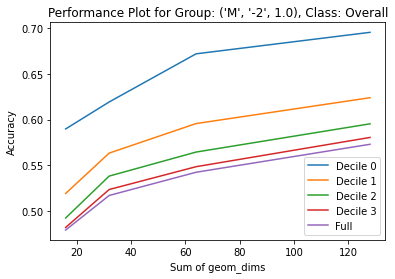

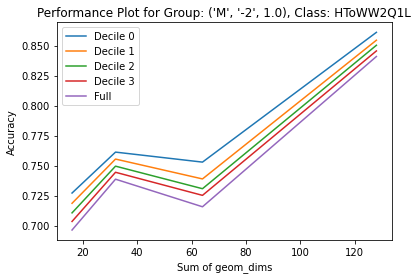

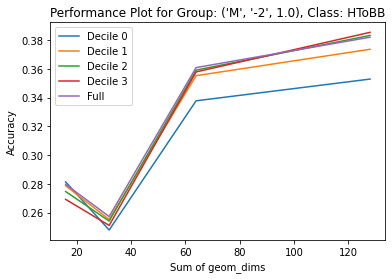

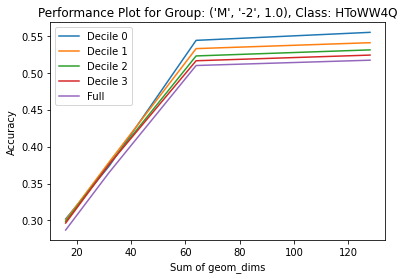

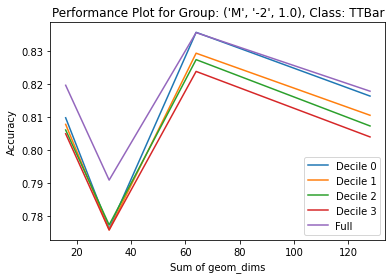

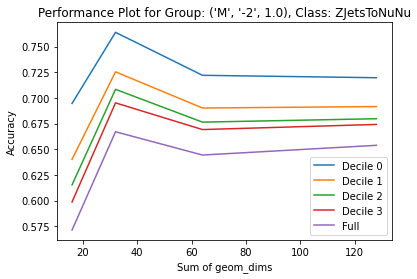

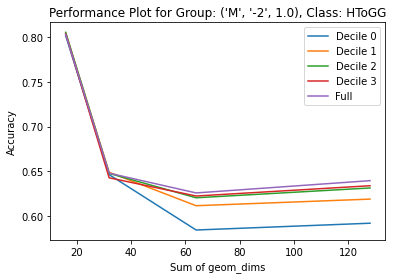

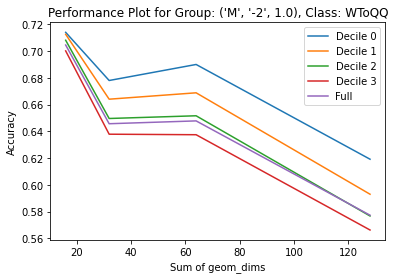

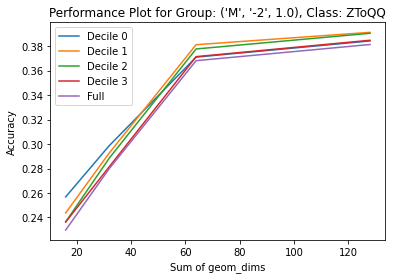

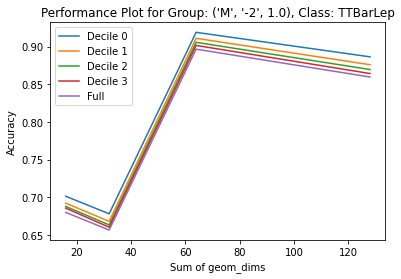

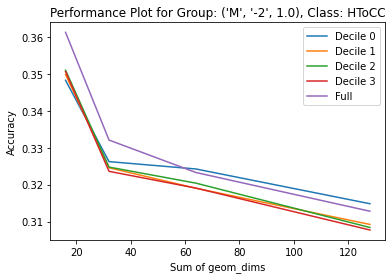

In [55]:
# ...existing code...
grouped = combined_accuracies_df.groupby(['geom','geom_curv', 'geom_ratio'])

for name, group in grouped:
    print(f"Group name: {name}")
    print("\n")
    for class_name in group['Class'].unique():
        class_data = group[group['Class'] == class_name]
        class_data = class_data.groupby(['geom', 'geom_curv', 'Level', 'Class', 'geom_dims', 'geom_ratio']).max().reset_index()
        
        plt.figure()
        for level in class_data['Level'].unique():
            level_data = class_data[class_data['Level'] == level]
            level_data = level_data.sort_values(by='total_geom_dim')
            plt.plot(level_data['total_geom_dim'], level_data['Accuracy'], label=level)
        
        plt.xlabel('Sum of geom_dims')
        plt.ylabel('Accuracy')
        plt.title(f'Performance Plot for Group: {name}, Class: {class_name}')
        plt.legend()
        plt.show()
    break
# ...existing code...

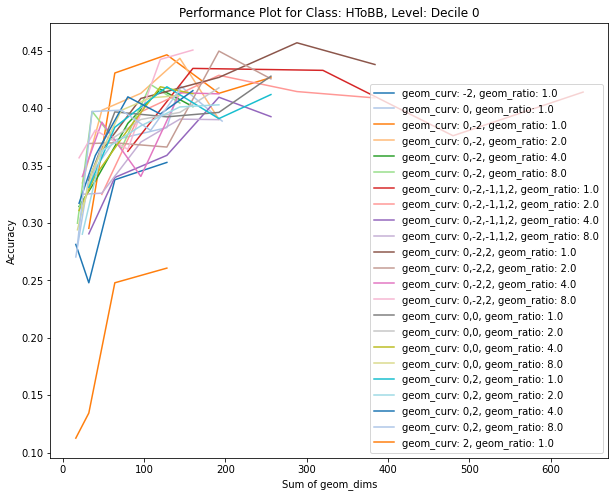

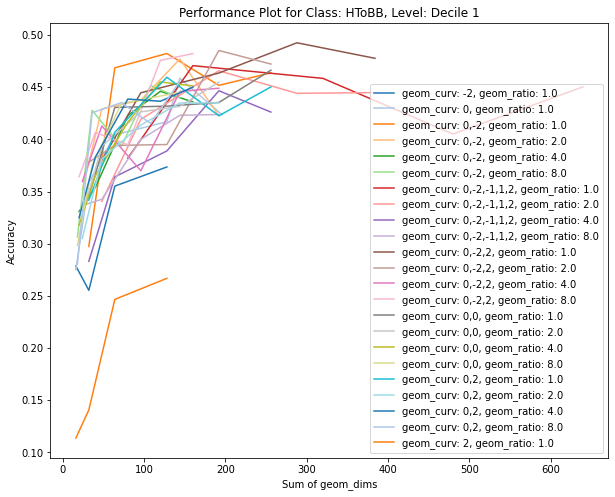

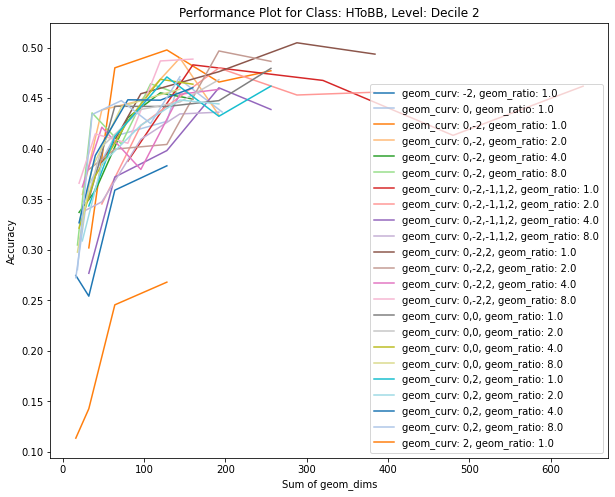

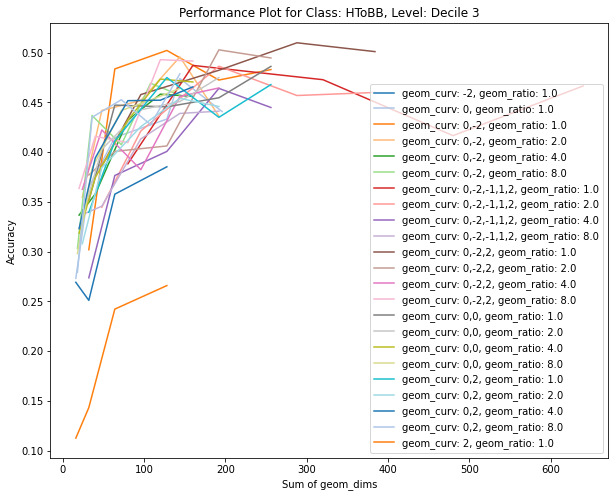

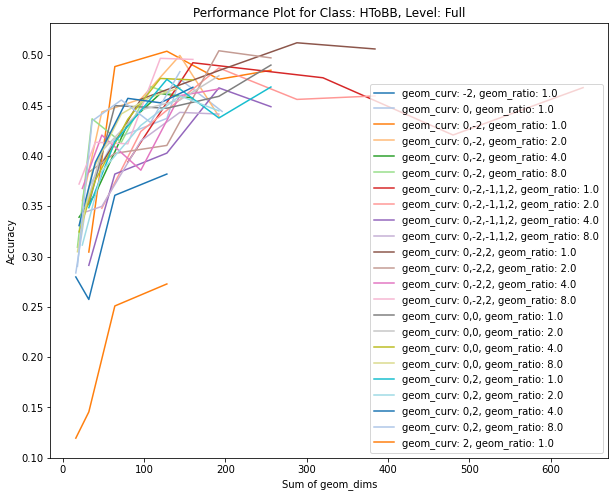

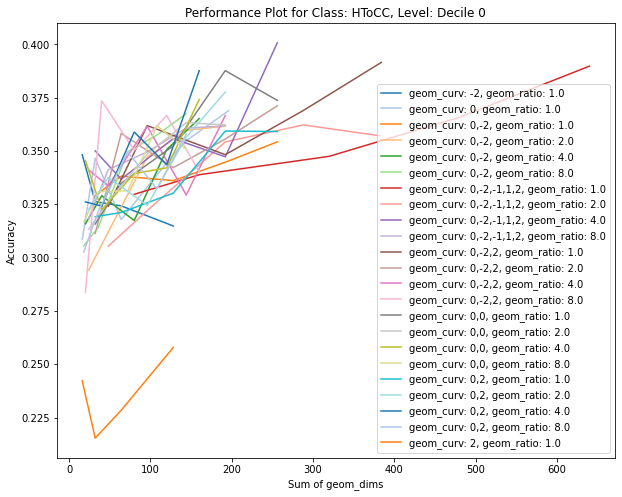

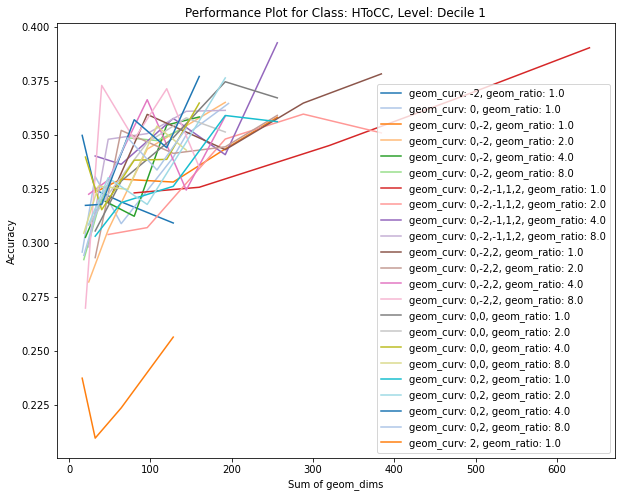

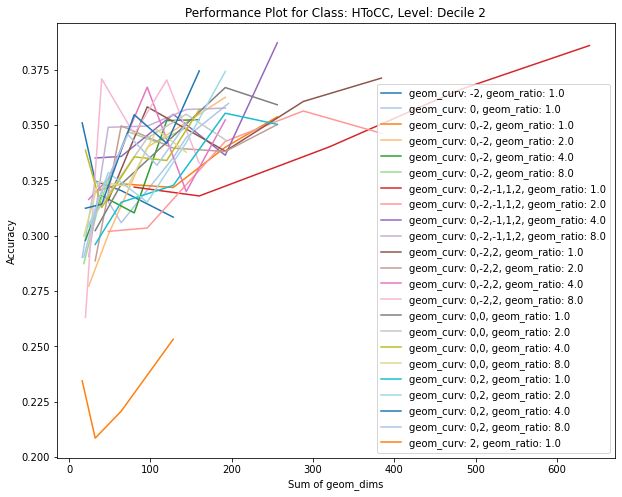

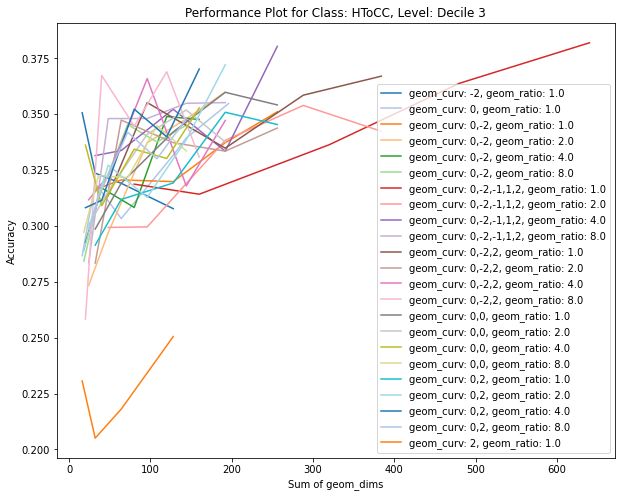

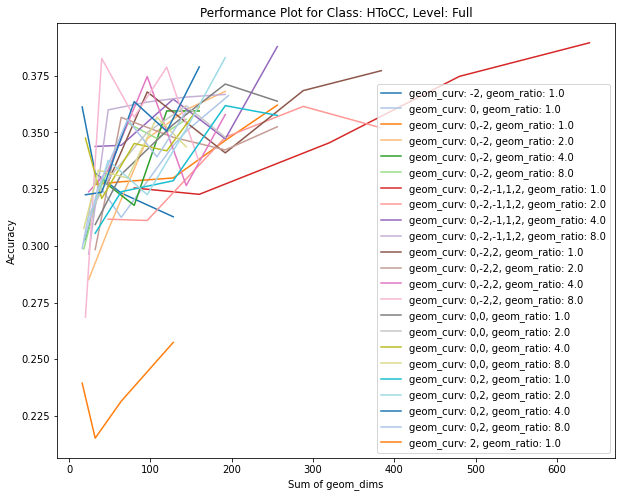

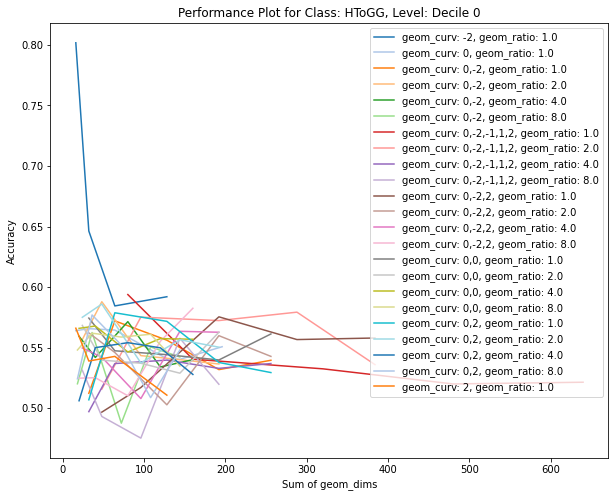

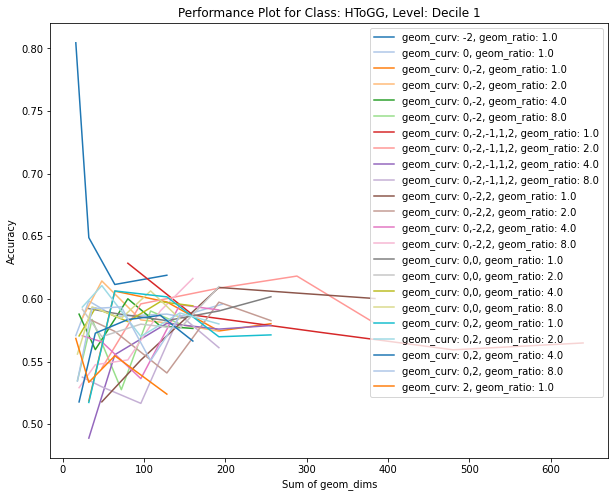

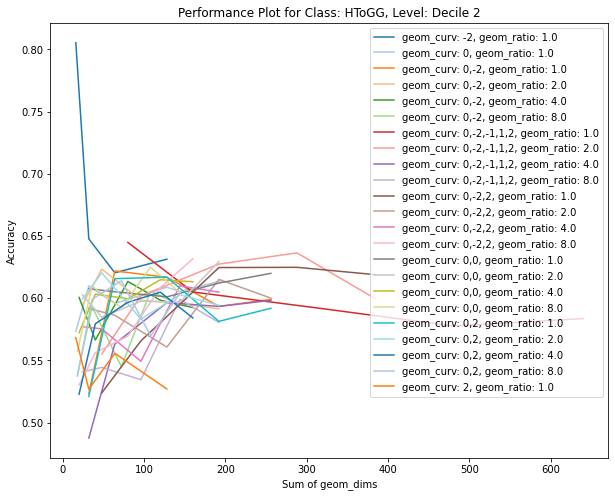

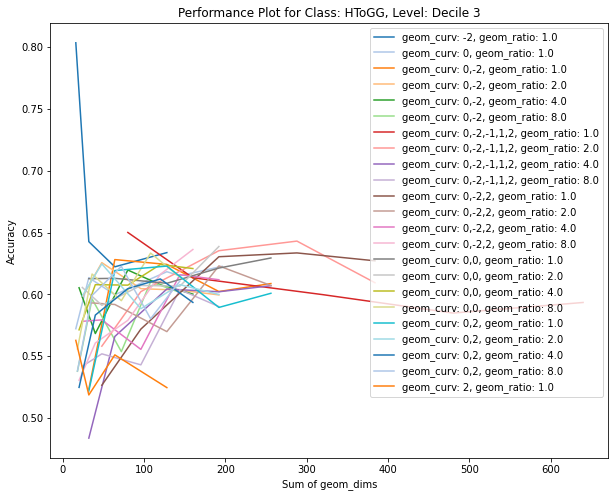

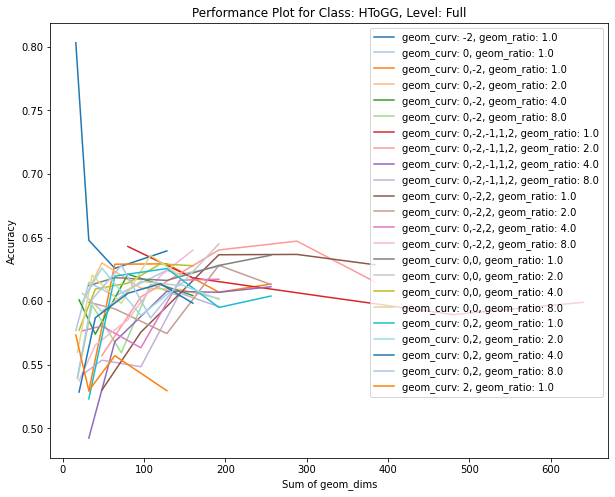

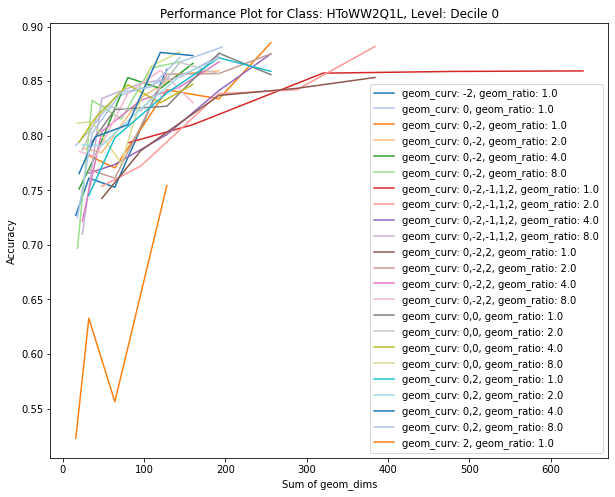

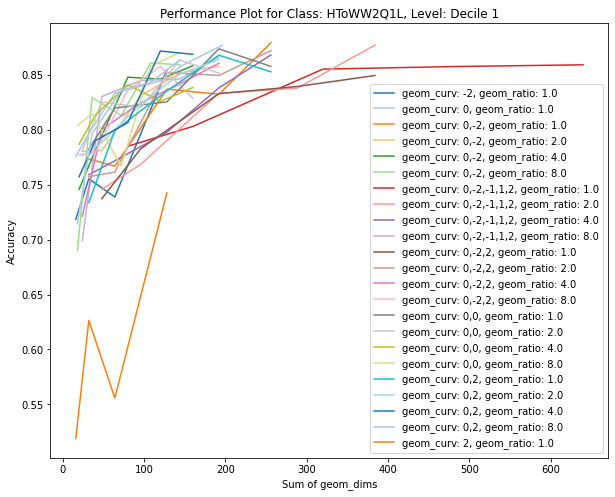

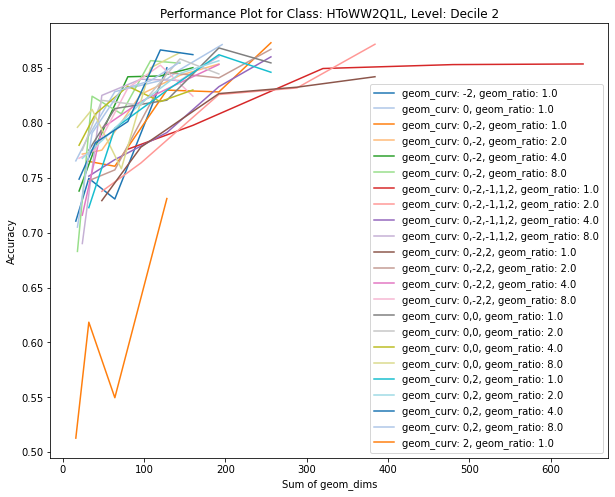

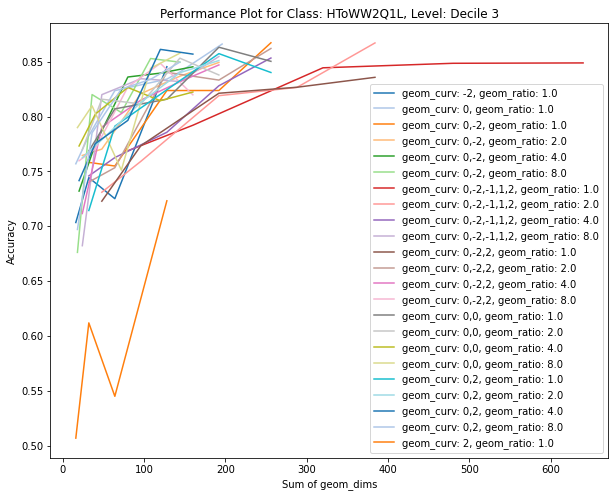

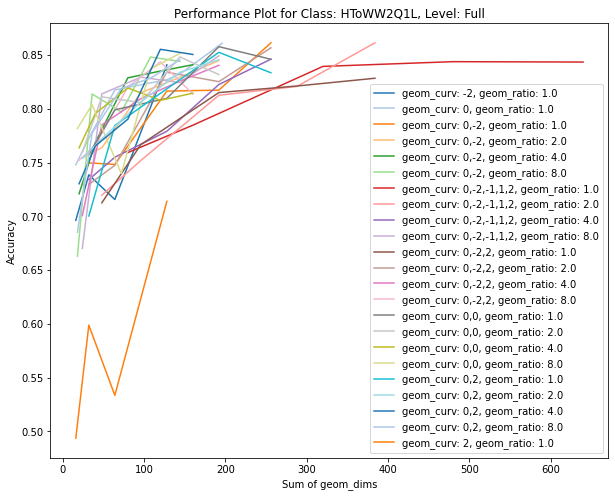

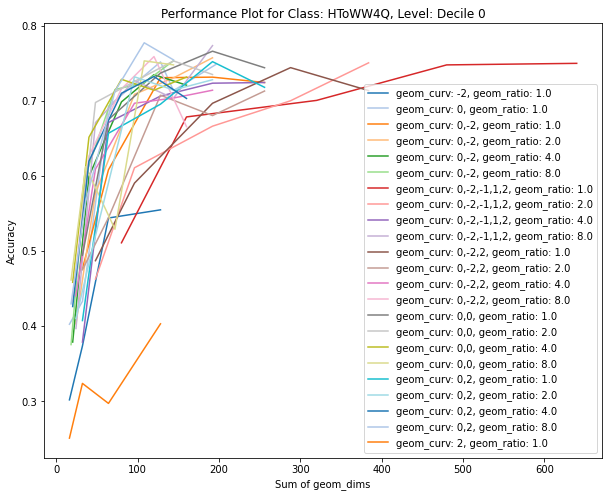

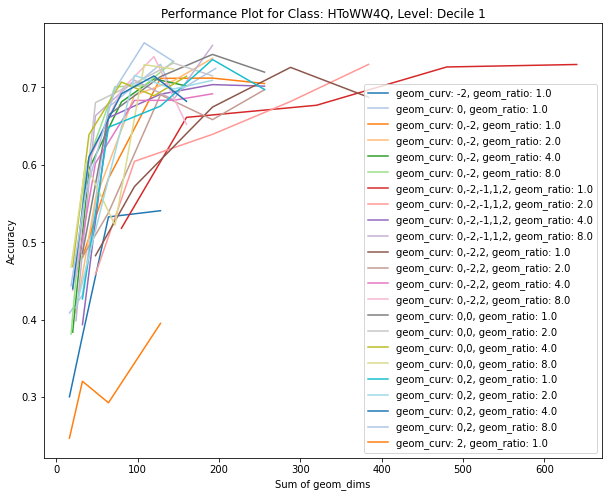

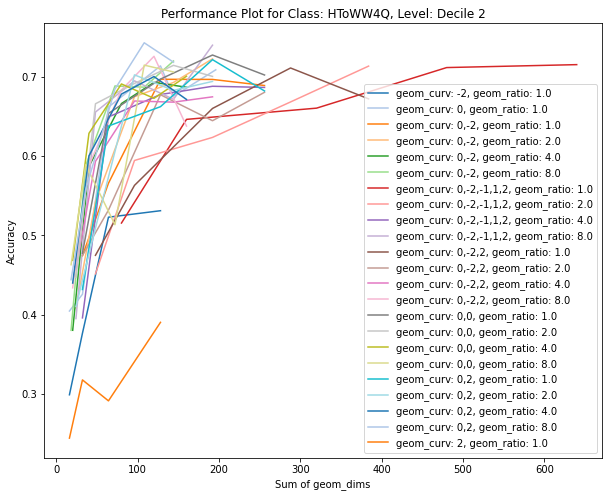

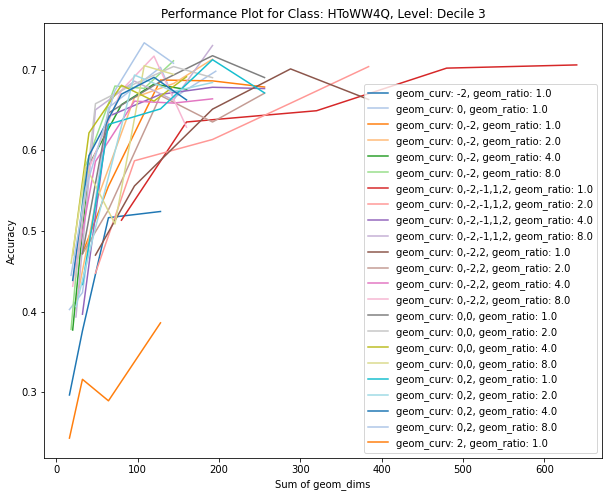

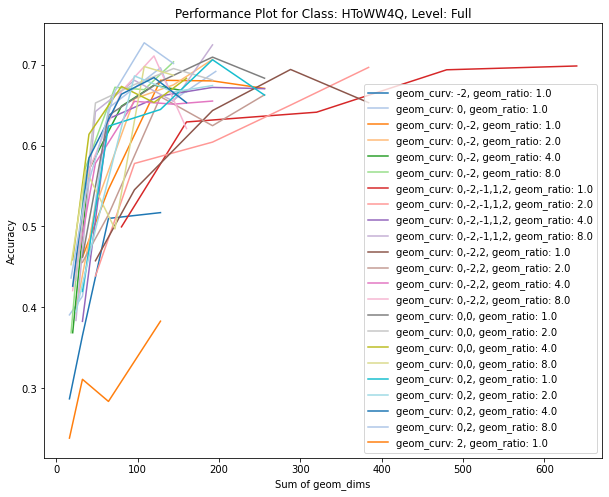

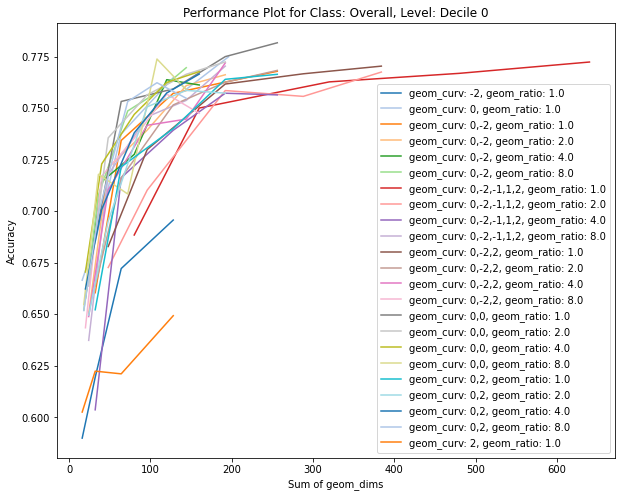

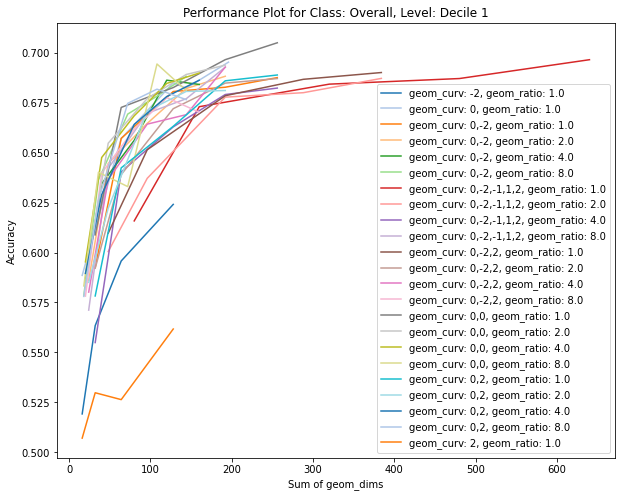

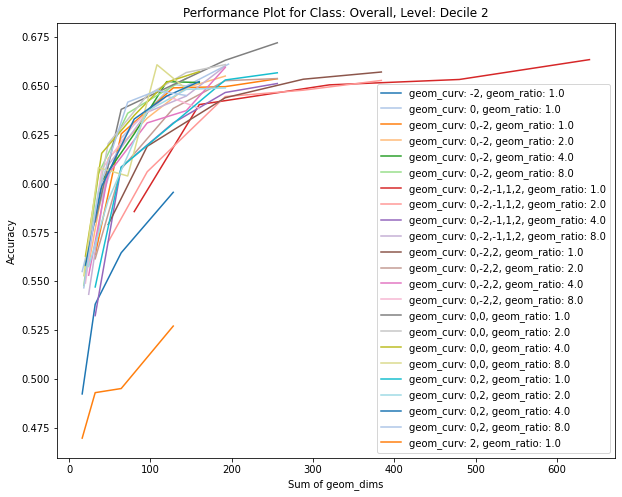

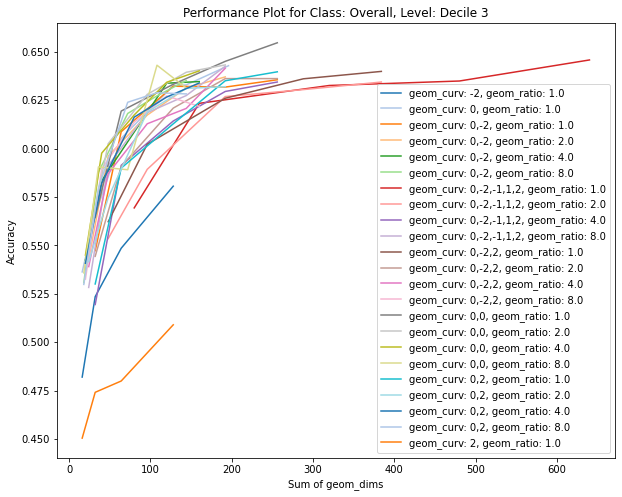

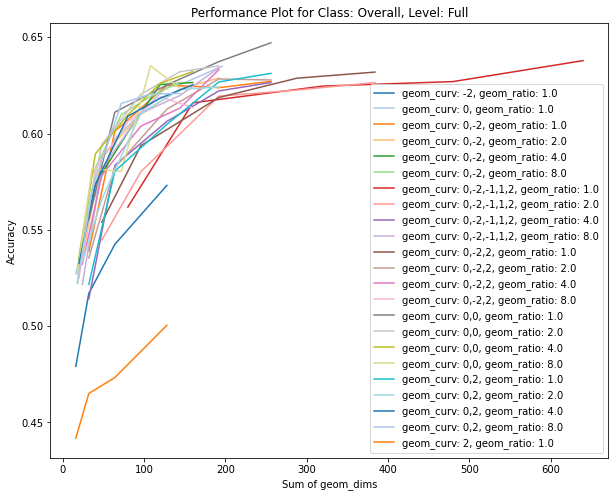

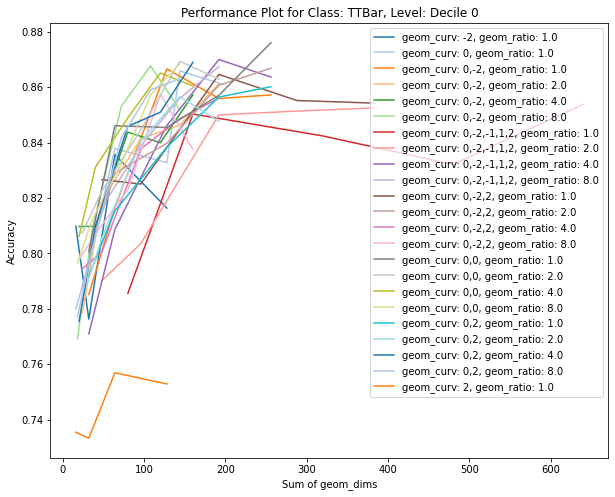

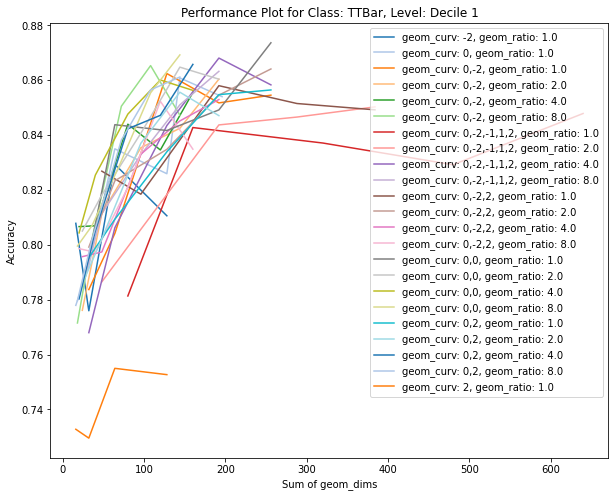

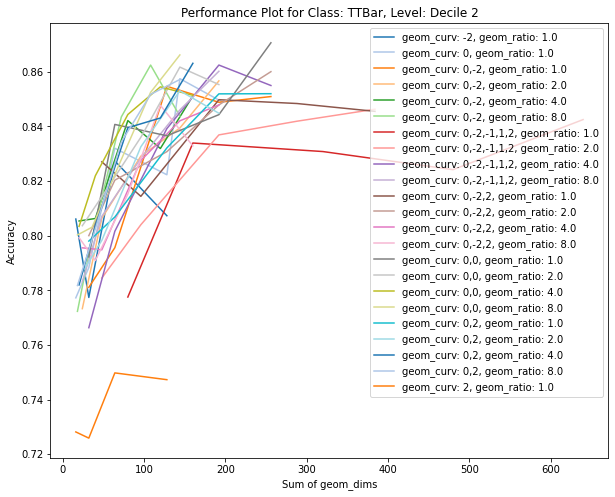

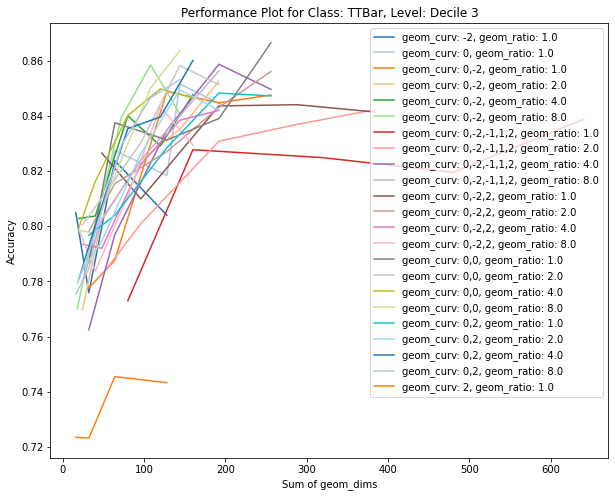

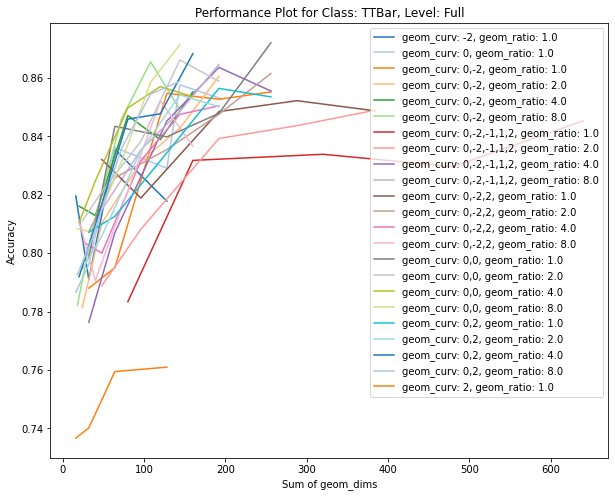

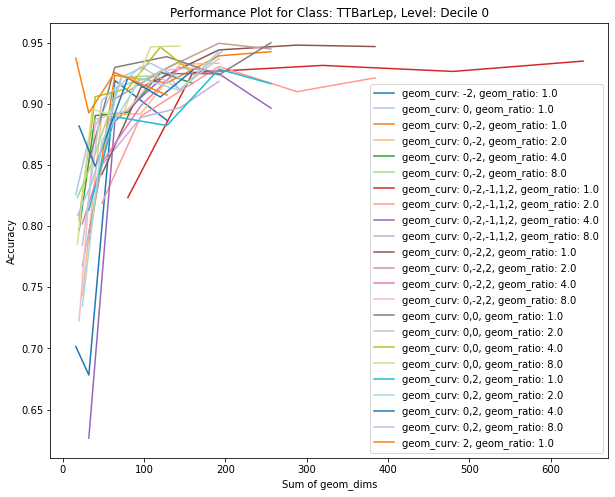

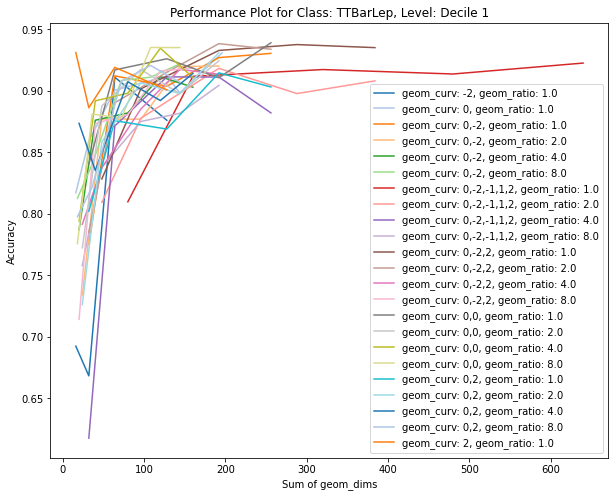

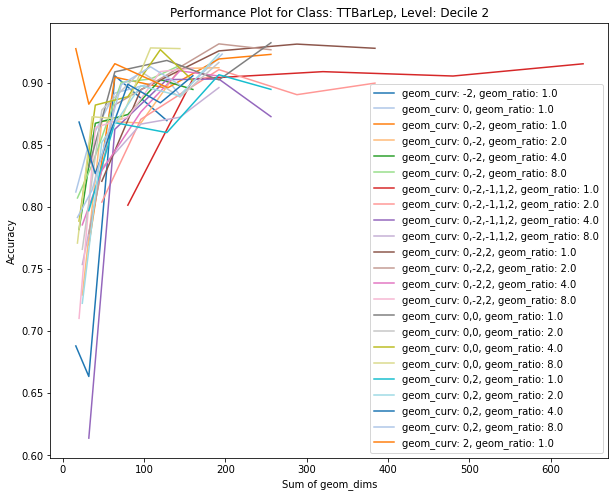

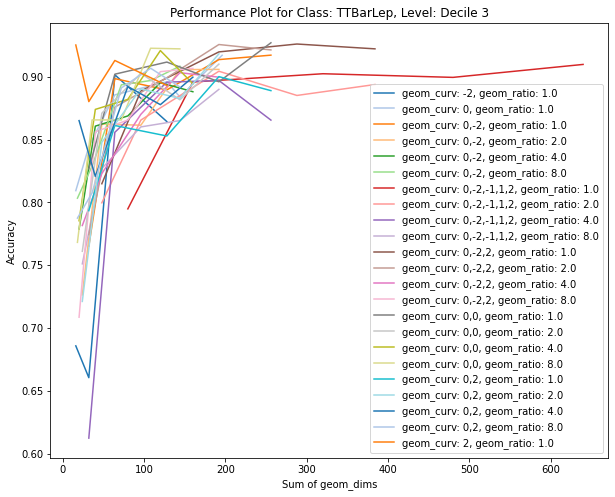

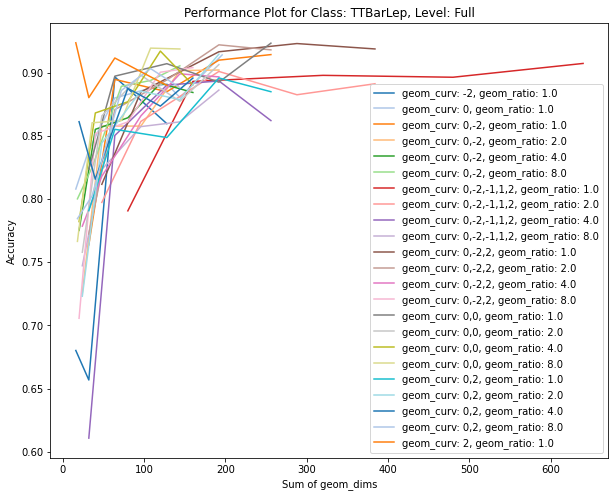

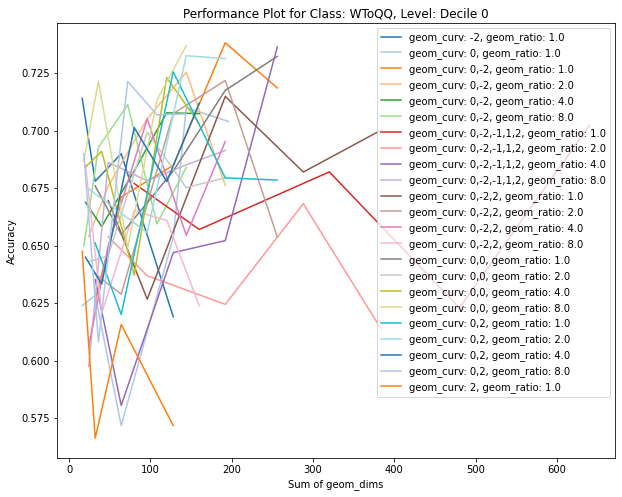

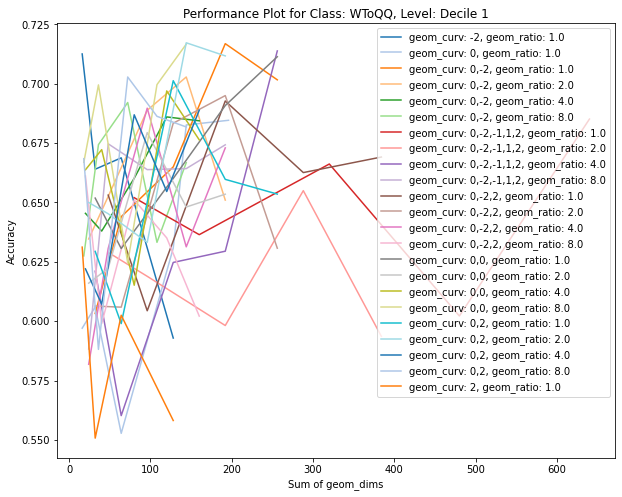

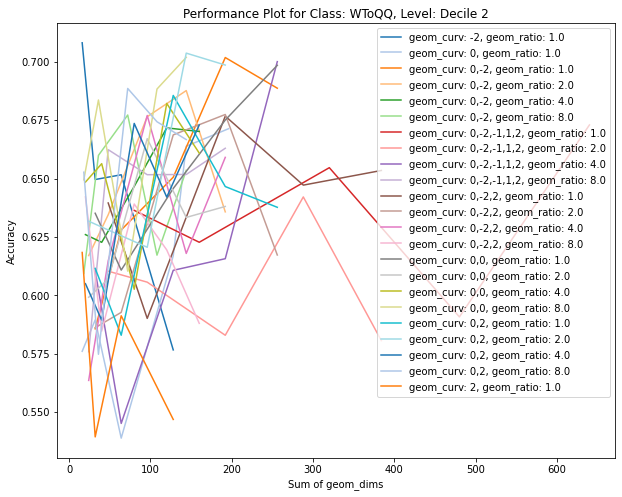

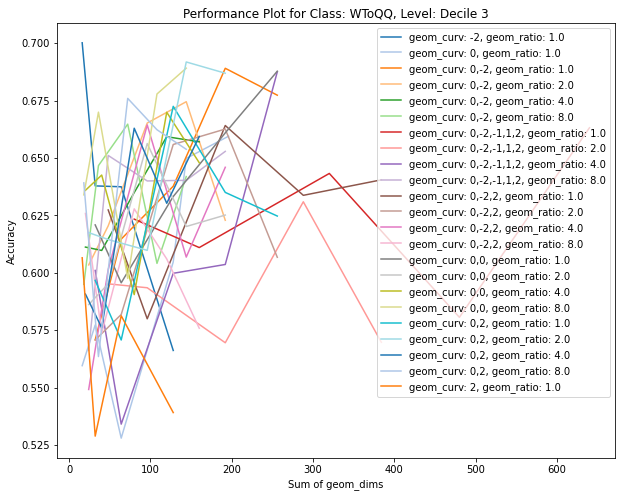

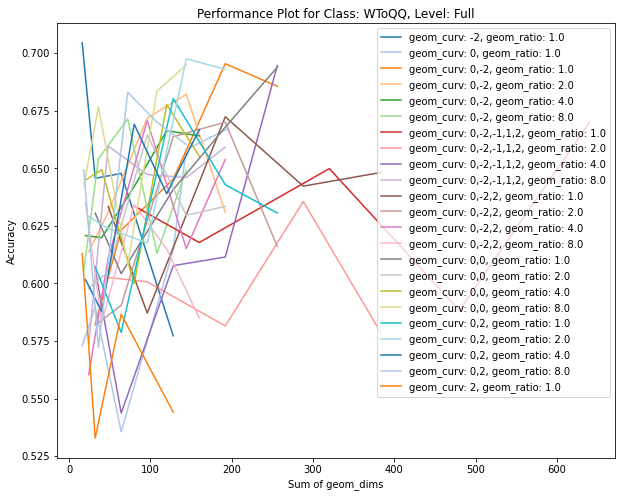

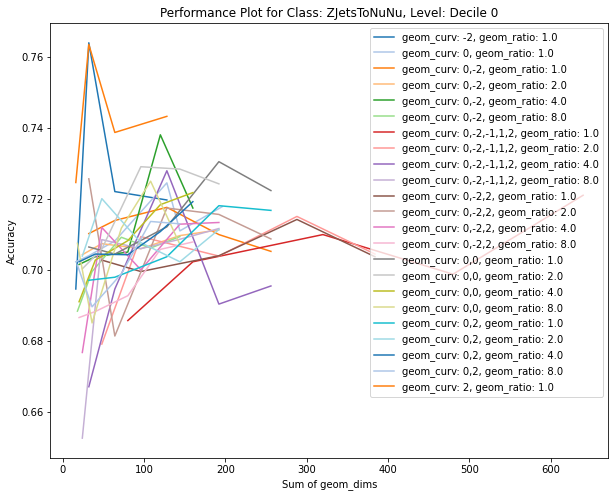

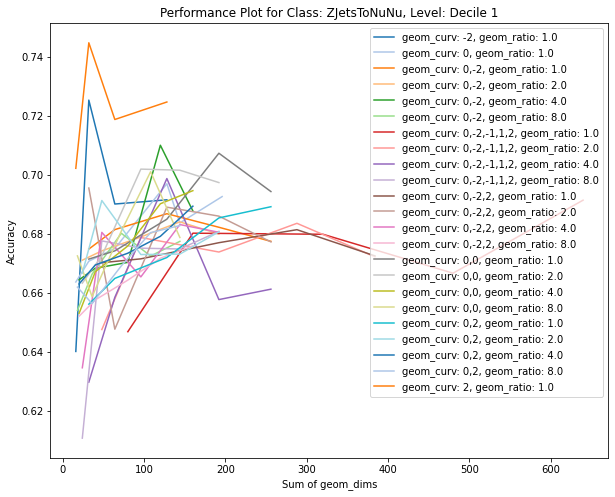

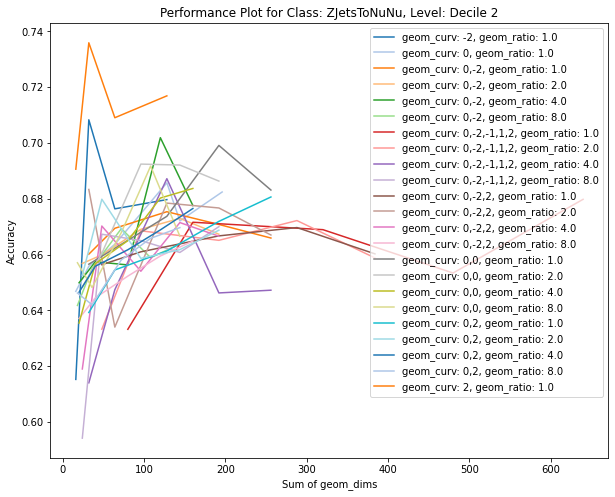

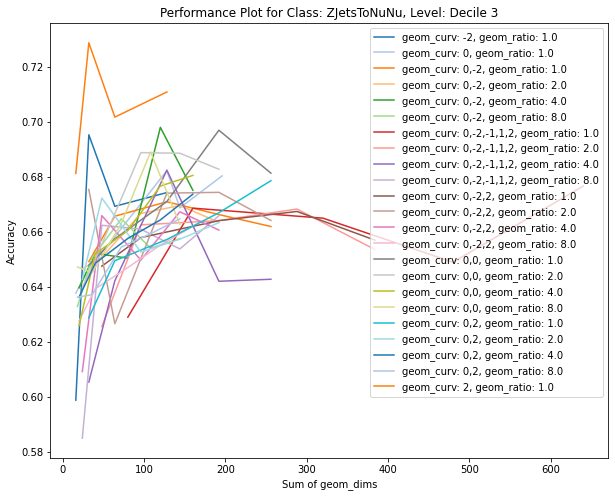

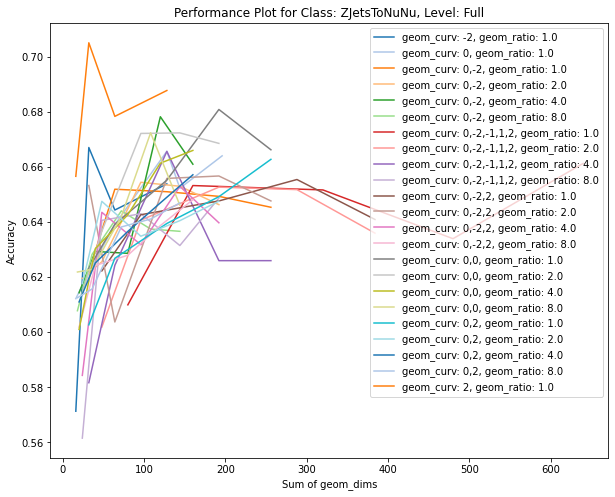

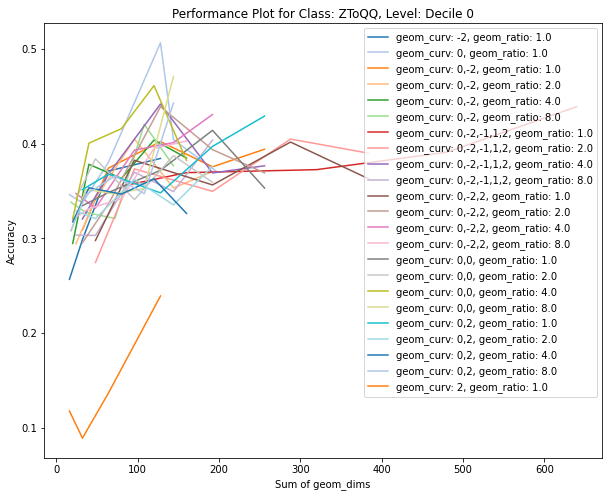

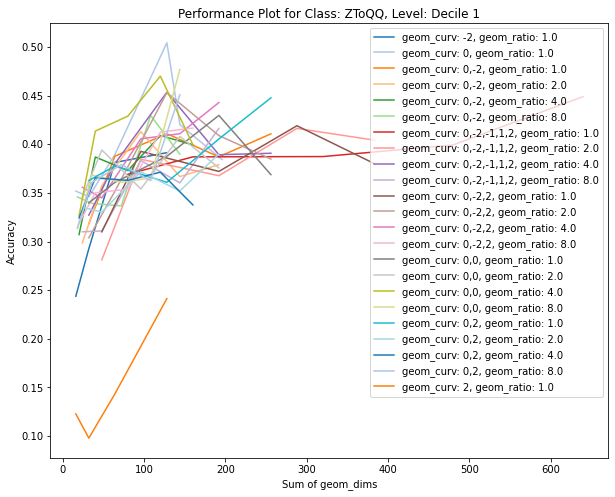

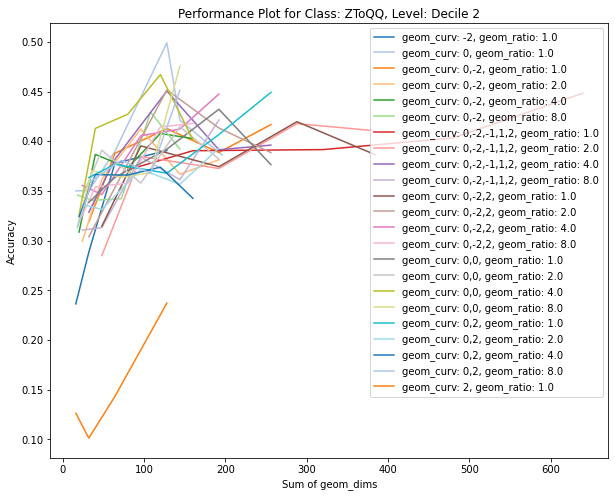

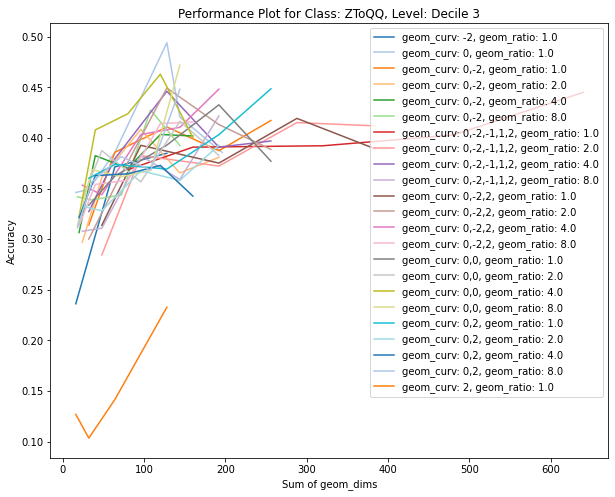

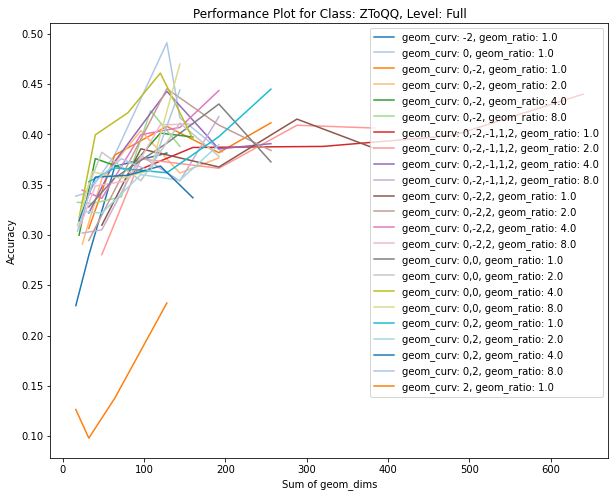

In [57]:
# ...existing code...
grouped = combined_accuracies_df.groupby(['Class', 'Level'])

for (class_name, level), group in grouped:
    plt.figure(figsize=(10, 8))
    color_cycle = plt.cm.tab20.colors
    color_idx = 0
    
    # Calculate the top 25% threshold for the entire group
    top_25_percent_threshold = group['Accuracy'].quantile(0.75)
    
    for (geom_curv, geom_ratio), geom_group in group.groupby(['geom_curv', 'geom_ratio']):
        geom_group = geom_group.sort_values(by='total_geom_dim')
        geom_group = geom_group.groupby('total_geom_dim').max().reset_index()
        
                
        if not geom_group.empty:
            plt.plot(geom_group['total_geom_dim'], 
                     geom_group['Accuracy'], 
                     label=f'geom_curv: {geom_curv}, geom_ratio: {geom_ratio}', 
                     color=color_cycle[color_idx % len(color_cycle)])
            color_idx += 1
    
    plt.xlabel('Sum of geom_dims')
    plt.ylabel('Accuracy')
    plt.title(f'Performance Plot for Class: {class_name}, Level: {level}')
    plt.legend()
    plt.show()
    


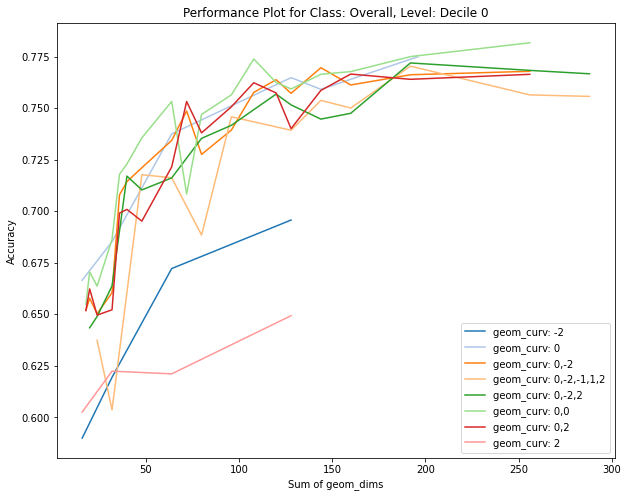

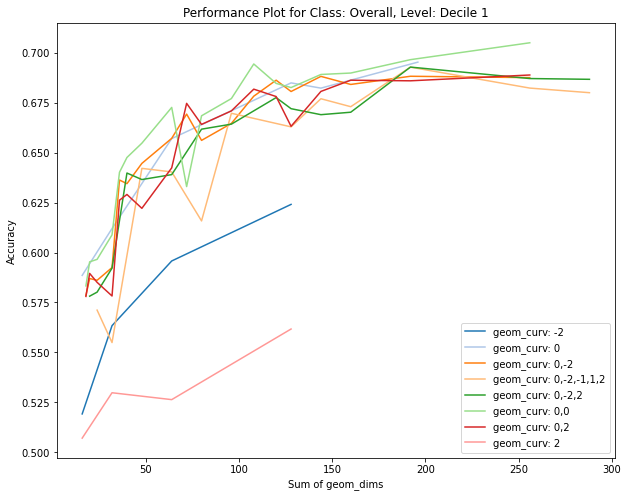

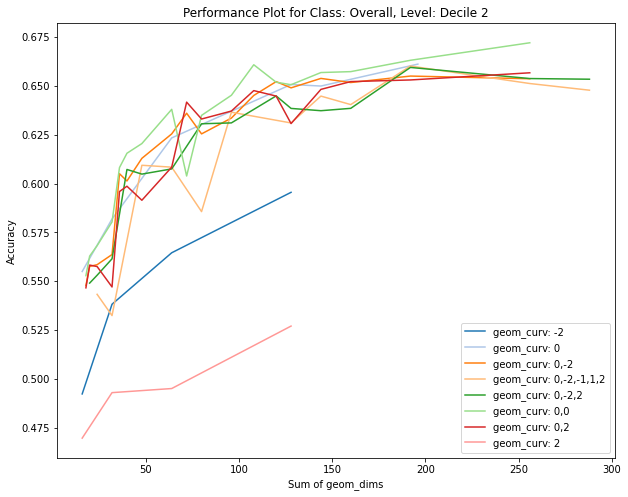

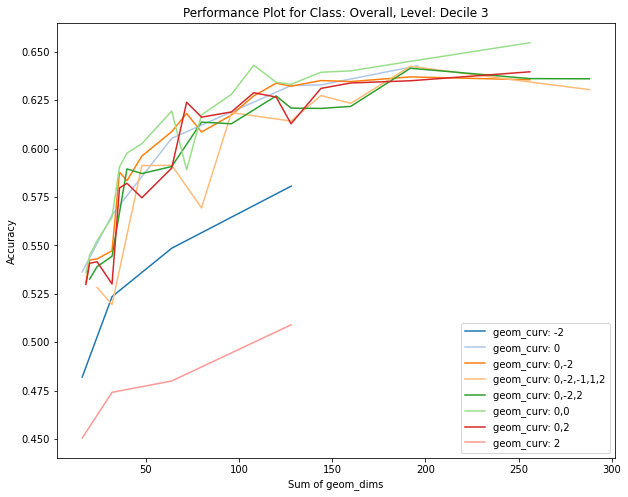

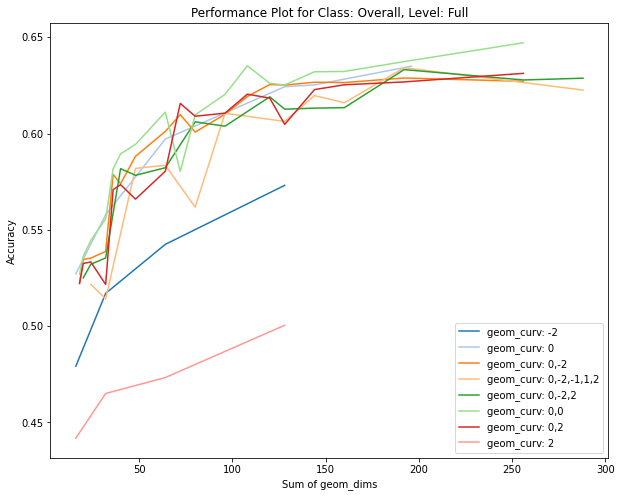

In [63]:
def plot_performance(grouped_df, classes_to_show=['Overall']):
    grouped = grouped_df.groupby(['Class', 'Level'])

    for (class_name, level), group in grouped:
        if class_name not in classes_to_show:
            continue
        
        plt.figure(figsize=(10, 8))
        color_cycle = plt.cm.tab20.colors
        color_idx = 0
        
        # Calculate the top 25% threshold for the entire group
        top_25_percent_threshold = group['Accuracy'].quantile(0.75)
        
        for geom_curv, geom_group in group.groupby('geom_curv'):
            geom_group = geom_group.sort_values(by='total_geom_dim')
            geom_group = geom_group.groupby('total_geom_dim').max().reset_index()
            
            # Filter out points with total_geom_dim > 400
            geom_group = geom_group[geom_group['total_geom_dim'] <= 300]
            
            if not geom_group.empty:
                plt.plot(geom_group['total_geom_dim'], 
                    geom_group['Accuracy'], 
                    label=f'geom_curv: {geom_curv}', 
                    color=color_cycle[color_idx % len(color_cycle)])
            color_idx += 1
        
        plt.xlabel('Sum of geom_dims')
        plt.ylabel('Accuracy')
        plt.title(f'Performance Plot for Class: {class_name}, Level: {level}')
        plt.legend()
        plt.show()

# Example usage
plot_performance(combined_accuracies_df, classes_to_show=['Overall'])
